# Geoloc

## infos
ligne 42368 : photo id 5464485473, correction -> les dates étaient décalée, le # de minutes (25) était collé au titre de la photo ("une lundi matin comme tout les autre ;-(") et le décalage était propagé.

pour les autres, on enleve les 142 lignes qui ont des valeurs non-nulles qui dépassent les colonnes attendues. (unnamed 16, y'a aussi 2 lignes avec des valeurs dans unnamed 18 mais elles sont comptabilisées dans les autres)

In [2]:
import numpy as np
import pandas as pd
import folium as fl
import plotly.express as px
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import hdbscan
from folium import plugins

In [3]:
read_data = pd.read_csv("./flickr_data2.csv")
read_data.drop_duplicates()
read_data.head()

/var/folders/c9/twn1wmwj03x9wl7kg5psv58r0000gn/T/ipykernel_51599/58792569.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  read_data = pd.read_csv("./flickr_data2.csv")


,id,user,lat,long,tags,title,date_taken_minute,date_taken_hour,date_taken_day,date_taken_month,date_taken_year,date_upload_minute,date_upload_hour,date_upload_day,date_upload_month,date_upload_year,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,4395181099,30624617@N03,45.754858,4.821710,"chair,lyon,rhône,chaise,rhônealpes",Chaises avec vue,11.0,15,28,2,2010,23,20,28.0,2,2010.0,NaN,NaN,NaN
1,4394748717,35853470@N00,45.753270,4.862953,NaN,NaN,51.0,17,28,2,2010,52,17,28.0,2,2010.0,NaN,NaN,NaN
2,4394694699,11817998@N05,45.760655,4.846564,"365,iphone",59/365 - R46 V103 B163,29.0,17,28,2,2010,33,17,28.0,2,2010.0,NaN,NaN,NaN
3,4394803790,11545749@N06,45.784000,4.874072,"nin,nineinchnails,gift,screening,toiou,avott",2010-01-29 Toiou Avott Lyon,15.0,20,28,1,2010,38,12,28.0,2,2010.0,NaN,NaN,NaN
4,4394803554,11545749@N06,45.784000,4.874072,"lyon,nin,nineinchnails,gift,screening,toiou,avott",2010-01-28 Toiou Avott Lyon,10.0,20,28,1,2010,38,12,28.0,2,2010.0,NaN,NaN,NaN


In [4]:
wrong_data = read_data.dropna(how="all", subset=read_data.columns[[16, 18]])
fix_data = read_data.drop(index=wrong_data.index, axis=1)

toDropColumns = read_data.columns[[16, 17, 18]]
fix_data = fix_data.drop(toDropColumns, axis=1)

fix_data.drop_duplicates(inplace=True, subset=fix_data.columns.drop(["id", " tags"]), keep='last')
fix_data.drop_duplicates(inplace=True, subset=fix_data.columns.drop(["id", " title"]))
#text_data = fix_data.dropna(how='all', subset=[" tags", " title"])


In [5]:
print(len(fix_data))
data2D = fix_data[[' lat', ' long']]
data2D.head()

161123


,lat,long
9420,45.767811,4.836215
9421,45.767811,4.836215
9422,45.760649,4.846391
9423,45.760846,4.827150
9424,45.761924,4.826399


## Partie sur la carte.

In [19]:
map = fl.Map(location=(45.757778, 4.832222), zoom_start = 13)

In [20]:
fl.Marker(
    location=[45.757778, 4.832222],
    tooltip="Clique moi !",
    popup="Centre de Lyon<br>(selon wikipedia)",
    icon=fl.Icon(icon_color="white", icon="info-sign", color="red"),
).add_to(map)

fl.Marker(
    location=[45.781883, 4.872814],
    tooltip="Clique moi !",
    popup="Ada Lovelace<br>(notre bâtiment)",
    icon=fl.Icon(icon_color="white", icon="book", color="blue"),
).add_to(map)

In [21]:
trail_coordinates = [
    (45.757778, 4.832222),
    (45.765482, 4.852781),
    (45.781883, 4.872814),
]

fl.PolyLine(trail_coordinates, tooltip="Coast", color="green").add_to(map)

In [22]:
map.save("test.html")

In [ ]:
data2D = np.ra

## Clustering avec K-Means

Première implémentation d'un algorithme de clustering simple basé sur les coordonnées géographiques.


In [10]:
# Extraire les coordonnées géographiques
donnees_geoloc = fix_data[[' lat', ' long']].copy()

print(f"Nombre de points avec coordonnées: {len(donnees_geoloc)}")
print(f"Latitude - min: {donnees_geoloc[' lat'].min()}, max: {donnees_geoloc[' lat'].max()}")
print(f"Longitude - min: {donnees_geoloc[' long'].min()}, max: {donnees_geoloc[' long'].max()}")

# Convertir en radians pour KMeans (données géographiques)
donnees_geoloc_rad = np.radians(donnees_geoloc)

# Appliquer K-Means avec k=50
nombre_clusters = 50
kmeans = KMeans(n_clusters=nombre_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(donnees_geoloc_rad)

donnees_geoloc_avec_clusters = donnees_geoloc.copy()
donnees_geoloc_avec_clusters['cluster'] = clusters

print(f"\nClusters créés: {nombre_clusters}")

print("\nDistribution des points par cluster:")
print(donnees_geoloc_avec_clusters['cluster'].value_counts().sort_index())

Nombre de points avec coordonnées: 161123
Latitude - min: 45.6552, max: 45.85495
Longitude - min: 4.720312, max: 5.006709

Clusters créés: 50

Distribution des points par cluster:
cluster
0     13940
1     11782
2       392
3      4518
4      3336
5      4911
6       961
7      2593
8     10713
9       638
10     1839
11      395
12      183
13     8359
14      606
15      709
16      708
17      511
18      200
19      880
20     4278
21     1358
22      794
23     1387
24    17010
25     5091
26     5343
27      245
28     2621
29    18193
30     3834
31     2168
32     5894
33      573
34      198
35      704
36      910
37      127
38     4066
39     2474
40      394
41     3039
42     6994
43      719
44      252
45      392
46      219
47     1173
48     1630
49      869
Name: count, dtype: int64


## Optimisation de la valeur de K pour le KMeans avec la méthode du coude

Avec la méthode du coude, nous essayerons de trouver la meilleure valeur de k

In [6]:
# Convertir data2D en radians pour KMeans et DBSCAN
data2D_rad = np.radians(data2D)

In [ ]:
range_k = range(50, 100, 5)
inertias = []
for i in range_k:
    # apply KMeans with i clusters
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=3)
    kmeans.fit(data2D_rad)

    inertias.append(kmeans.inertia_)


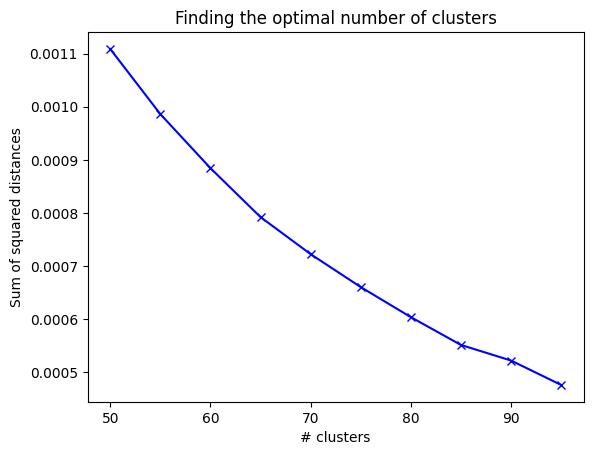

In [12]:
# Visualisation

n = len(inertias)
xticks_new = np.arange(50, 100, 5)
plt.plot(xticks_new, inertias[0:n], 'bx-')
plt.title('Finding the optimal number of clusters')
plt.xlabel('# clusters')
plt.ylabel('Sum of squared distances')
plt.show()

In [ ]:
# Visualisation

n = 30
xticks_new = np.arange(1, n+1)
plt.plot(xticks_new, inertias[0:n], 'bx-')
plt.title('Finding the optimal number of clusters')
plt.xlabel('# clusters')
plt.ylabel('Sum of squared distances')
plt.show()

## Validation de k=100 avec la méthode du silhouette score

Après avoir trouvé k=50 avec la méthode du coude, on vérifie ce choix avec le silhouette score.


In [13]:
# Appliquer K-Means avec k=100 (choisi par la méthode du coude)
nombre_clusters = 100
kmeans = KMeans(n_clusters=nombre_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data2D_rad)

donnees_geoloc_avec_clusters = data2D.copy()
donnees_geoloc_avec_clusters['cluster'] = clusters

print(f"Clusters créés: {nombre_clusters}")
print("\nDistribution des points par cluster:")
print(donnees_geoloc_avec_clusters['cluster'].value_counts().sort_index())


Clusters créés: 100

Distribution des points par cluster:
cluster
0       861
1      5698
2     11034
3      3232
4      3991
      ...  
95      766
96     2647
97     3322
98    11349
99      159
Name: count, Length: 100, dtype: int64


In [14]:
labels = kmeans.labels_
print(f"k-means labels : {labels}")

k-means labels : [85 85 58 ... 97 97 33]


In [15]:
donnees_geoloc_avec_clusters['cluster'] = labels
donnees_geoloc_avec_clusters.head()

,lat,long,cluster
9420,45.767811,4.836215,85
9421,45.767811,4.836215,85
9422,45.760649,4.846391,58
9423,45.760846,4.827150,98
9424,45.761924,4.826399,98


In [ ]:


sample_size = 50000  
indices = np.random.choice(len(data2D_rad), sample_size, replace=False)

x_sample = data2D_rad.iloc[indices]
labels_sample = labels[indices]

sample_silhouette_values = silhouette_samples(
    x_sample,
    labels_sample,
    metric="euclidean"
)

silhouette_avg = sample_silhouette_values.mean()
print(f"Silhouette score moyen pour k=100: {silhouette_avg:.3f}")
print(f"\nInterprétation:")
if silhouette_avg > 0.5:
    print(" Excellent: Les clusters sont bien séparés et cohésifs")
elif silhouette_avg > 0.4:
    print(" Bon: Les clusters sont correctement formés")
elif silhouette_avg > 0.25:
    print(" Moyen: La structure des clusters est faible")
else:
    print("Mauvais: Les clusters ne sont pas bien définis")

Silhouette score moyen pour k=50: 0.519

Interprétation:
 Excellent: Les clusters sont bien séparés et cohésifs


## Clustering avec DBSCAN 

On applique le clustering avec DBSCAN

In [7]:
def find_optimal_eps(data, min_pts):
    # Convertir en radians pour haversine (données géographiques)
    data_rad = np.radians(data)
    
    # Calculer les distances avec haversine
    neigh = NearestNeighbors(n_neighbors=min_pts, metric='haversine')
    neigh.fit(data_rad)
    distances, _ = neigh.kneighbors(data_rad)

    # Sort les distances
    k_distances = np.sort(distances[:, min_pts - 1])

    # Create plot avec matplotlib
    plt.figure(figsize=(10, 6))
    plt.plot(k_distances, 'b-')
    plt.ylabel(f'Distance to {min_pts}th nearest neighbor (haversine)')
    plt.xlabel('Points sorted by distance')
    plt.title(f'K-distance Graph (k={min_pts})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return k_distances


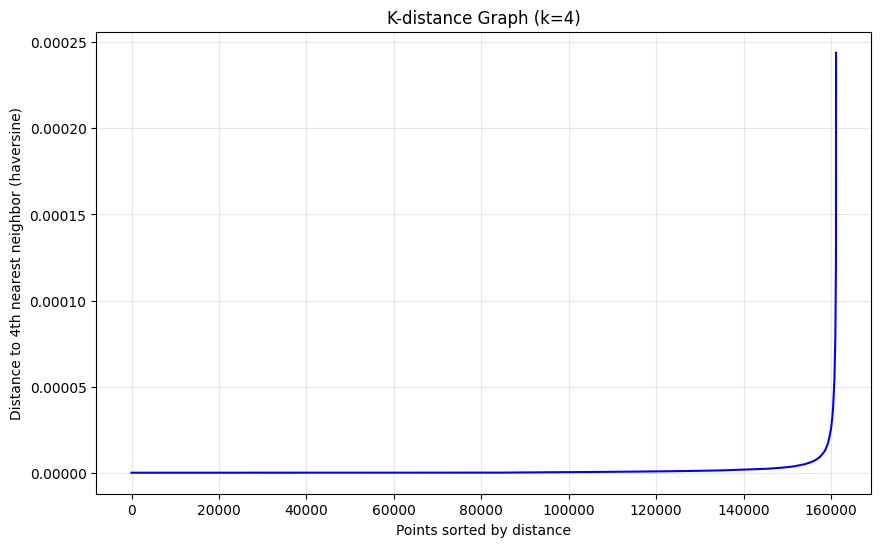


Distance médiane: 0.000000
Distance 75e percentile: 0.000001
Distance 90e percentile: 0.000002

Suggestion: utiliser eps entre 0.000001 et 0.000002


In [8]:
k_distances = find_optimal_eps(data2D, min_pts=4)


print(f"\nDistance médiane: {np.median(k_distances):.6f}")
print(f"Distance 75e percentile: {np.percentile(k_distances, 75):.6f}")
print(f"Distance 90e percentile: {np.percentile(k_distances, 90):.6f}")
print(f"\nSuggestion: utiliser eps entre {np.percentile(k_distances, 75):.6f} et {np.percentile(k_distances, 90):.6f}")


## Appliquer DBScan avec les bons paramètres

In [13]:
sample_size = 10000  
indices = np.random.choice(len(data2D_rad), sample_size, replace=False)

x_sample = data2D_rad.iloc[indices]
best_eps = 2
best_min_samples = 100
# Appliquer DBScan avec données en radians
best_dbscan = DBSCAN(eps = best_eps, min_samples=best_min_samples, metric='haversine')
best_labels = best_dbscan.fit_predict(x_sample)


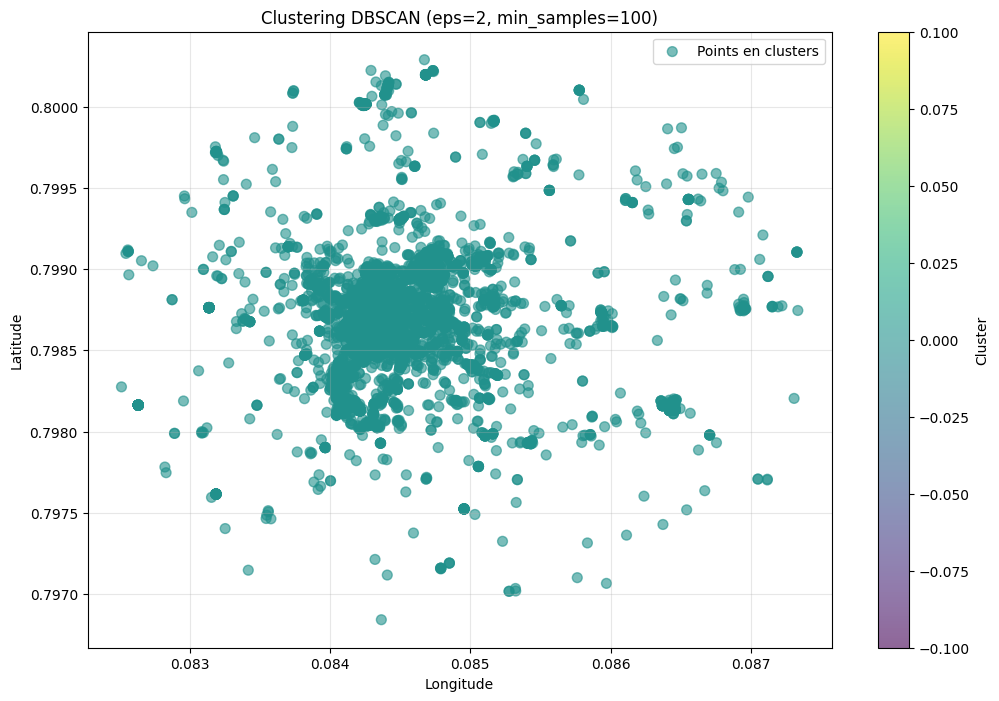


Distribution des points par cluster:
Cluster 0: 10000 points


In [14]:
# Visualiser les clusters DBSCAN
plt.figure(figsize=(12, 8))

# Séparer les points en cluster et les outliers
is_noise = best_labels == -1
is_cluster = best_labels != -1

# Tracer les points des clusters
if is_cluster.sum() > 0:
    scatter = plt.scatter(x_sample.loc[is_cluster, ' long'],
                         x_sample.loc[is_cluster, ' lat'],
                         c=best_labels[is_cluster],
                         cmap='viridis',
                         alpha=0.6,
                         s=50,
                         label='Points en clusters')

# Tracer les outliers en noir
if is_noise.sum() > 0:
    plt.scatter(x_sample.loc[is_noise, ' long'],
               x_sample.loc[is_noise, ' lat'],
               c='red',
               marker='x',
               s=100,
               alpha=0.5,
               label=f'Bruit ({is_noise.sum()} points)')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Clustering DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
plt.legend()
plt.grid(True, alpha=0.3)
if is_cluster.sum() > 0:
    plt.colorbar(label='Cluster')
plt.show()

print(f"\nDistribution des points par cluster:")
unique, counts = np.unique(best_labels[is_cluster], return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} points")


In [55]:
# Analyser les résultats
n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise = list(best_labels).count(-1)

print(f"Paramètres DBSCAN:")
print(f"  eps: {best_eps}")
print(f"  min_samples: {best_min_samples}")
print(f"\nRésultats:")
print(f"  Nombre de clusters: {n_clusters}")
print(f"  Nombre de points de bruit (outliers): {n_noise}")
print(f"  Pourcentage de bruit: {100*n_noise/len(donnees_geoloc):.1f}%")
print(f"  Nombre de points en clusters: {len(donnees_geoloc) - n_noise}")


Paramètres DBSCAN:
  eps: 30
  min_samples: 100

Résultats:
  Nombre de clusters: 212
  Nombre de points de bruit (outliers): 49908
  Pourcentage de bruit: 11.9%
  Nombre de points en clusters: 370190


## Teste du clustering avec HDBSCAN

In [7]:
coords_rad = np.radians(data2D)
coords_rad.head()

,lat,long
9420,0.798799,0.084408
9421,0.798799,0.084408
9422,0.798674,0.084585
9423,0.798677,0.084250
9424,0.798696,0.084237


In [15]:

clusterer = hdbscan.HDBSCAN(min_cluster_size = 100, min_samples = 50, metric= 'haversine')
labels = clusterer.fit_predict(coords_rad)
df = data2D.copy()
df["cluster"] = labels
pois = (
    df[df.cluster != -1]
    .groupby("cluster")
    .agg(
        lat_mean=(" lat", "mean"),
        lon_mean=(" long", "mean"),
        nb_photos=("cluster", "count")
    )
    .sort_values("nb_photos", ascending=False)
)

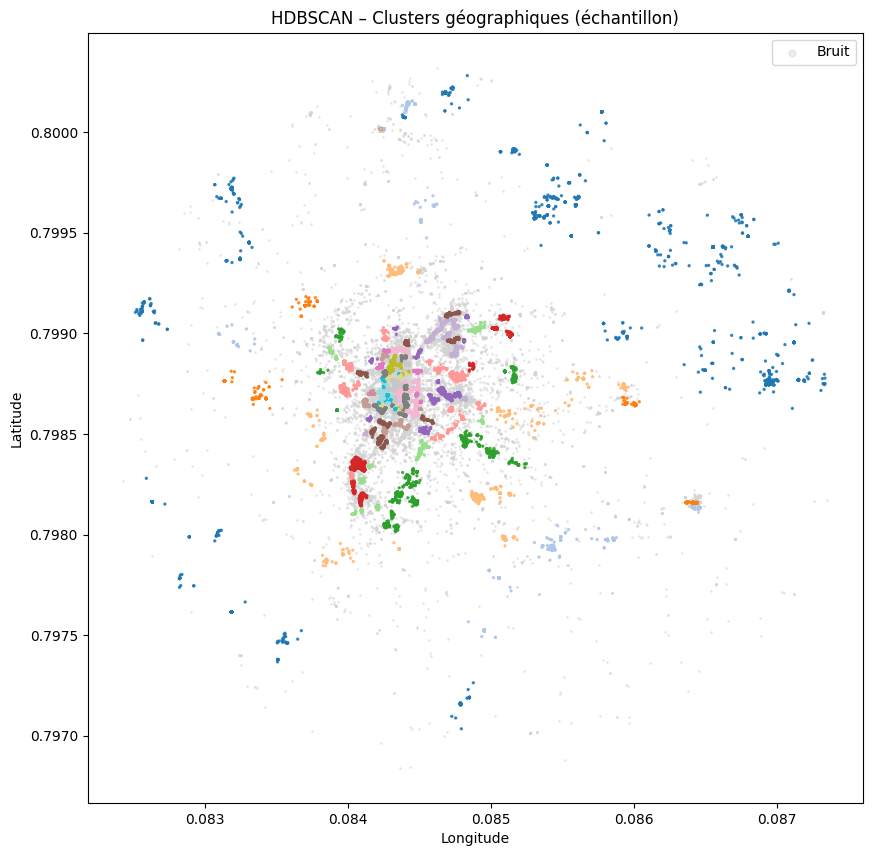

In [17]:
plt.figure(figsize=(10, 10))
# Prendre un échantillon pour la visualisation
sample_size = 50000
indices = np.random.choice(len(coords_rad), sample_size, replace=False)
coords_rad_sample = coords_rad.iloc[indices].values
labels_sample = labels[indices]

# Bruit
mask_noise = labels_sample == -1
plt.scatter(
    coords_rad_sample[mask_noise, 1],
    coords_rad_sample[mask_noise, 0],
    s=1,
    c='lightgrey',
    alpha=0.4,
    label='Bruit'
)

# Clusters
mask_cluster = labels_sample != -1
plt.scatter(
    coords_rad_sample[mask_cluster, 1],
    coords_rad_sample[mask_cluster, 0],
    s=2,
    c=labels_sample[mask_cluster],
    cmap='tab20',
    alpha=0.8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("HDBSCAN – Clusters géographiques (échantillon)")
plt.legend(markerscale=5)
plt.show()


In [18]:
# Créer une carte avec les clusters HDBSCAN

# Réinitialiser les indices pour éviter les problèmes
data2D_reset = data2D.reset_index(drop=True)
labels_reset = labels.copy()

# Créer la carte centrée sur Lyon
map_hdbscan = fl.Map(
    location=[45.757778, 4.832222],
    zoom_start=12
)

# Couleurs pour les clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 
          'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'white', 'pink', 'gray']

# Ajouter les points avec les couleurs des clusters
for idx in range(len(data2D_reset)):
    cluster_id = labels_reset[idx]
    row = data2D_reset.iloc[idx]
    
    # Sauter le bruit (cluster -1)
    if cluster_id == -1:
        continue
    
    # Choisir la couleur selon le cluster
    color = colors[int(cluster_id) % len(colors)]
    
    # Ajouter un marqueur
    fl.CircleMarker(
        location=[row[' lat'], row[' long']],
        radius=3,
        popup=f'Cluster {cluster_id}',
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=1
    ).add_to(map_hdbscan)

# Ajouter les points de bruit en gris transparent
for idx in range(len(data2D_reset)):
    if labels_reset[idx] == -1:
        row = data2D_reset.iloc[idx]
        fl.CircleMarker(
            location=[row[' lat'], row[' long']],
            radius=1,
            popup='Bruit',
            color='gray',
            fill=True,
            fillColor='gray',
            fillOpacity=0.2,
            weight=0.5
        ).add_to(map_hdbscan)

# Ajouter les centres des clusters (POIs)
for cluster_id, poi_row in pois.iterrows():
    fl.Marker(
        location=[poi_row['lat_mean'], poi_row['lon_mean']],
        popup=f"Cluster {cluster_id}<br>{int(poi_row['nb_photos'])} photos",
        icon=fl.Icon(color=colors[int(cluster_id) % len(colors)], icon='info-sign')
    ).add_to(map_hdbscan)

# Sauvegarder la carte
map_hdbscan.save('map_hdbscan.html')
print("Carte HDBSCAN sauvegardée dans 'map_hdbscan.html'")
print(f"\nRésumé des clusters HDBSCAN:")
print(pois)


Carte HDBSCAN sauvegardée dans 'map_hdbscan.html'

Résumé des clusters HDBSCAN:
          lat_mean  lon_mean  nb_photos
cluster                                
32       45.837448  4.826248       3748
93       45.732627  4.818266       2352
95       45.741761  4.817054       2174
33       45.837410  4.826163       2159
297      45.760934  4.826797       2024
...            ...       ...        ...
104      45.769939  4.862766        103
247      45.770564  4.834030        103
7        45.690163  4.786463        102
274      45.766609  4.826910        101
114      45.771234  4.845757        100

[299 rows x 3 columns]
